In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

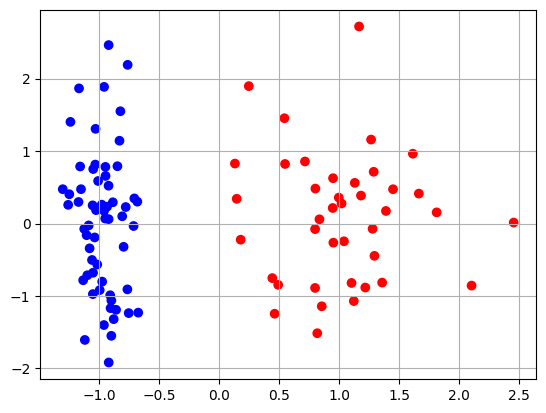

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_classes=2, random_state=42, 
                           n_informative=1, n_redundant=0, n_clusters_per_class=1, hypercube=True,
                           weights=[0.6, 0.4], class_sep=1.0)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.grid()
plt.show()

In [3]:
df = pd.DataFrame(np.column_stack((X,y)), columns=['Feature_1', 'Feature_2', 'Target'])
df.head()

,Feature_1,Feature_2,Target
0,-1.153827,0.473833,0.0
1,-0.715082,-0.034712,0.0
2,1.288046,0.714000,1.0
3,0.949001,0.625667,1.0
4,1.294432,-0.446515,1.0


In [4]:
def step(z):
    return 1 if z>0 else 0

In [5]:
def perceptron_trick(X, y, lr, epochs):
    X = np.insert(X, 0, 1, axis=1)
    n, m = X.shape
    weights = np.ones(m) #(m,) 

    for i in tqdm(range(epochs)):
        j = np.random.randint(low=0, high=n)
        # Xj -> (m,)
        z = np.dot(X[j], weights)
        y_hat = step(z)

        weights += lr * (y[j] - y_hat) * X[j]
    return weights[0], weights[1:] 


In [6]:
intercept, coef = perceptron_trick(X, y, lr=1e-2, epochs=1000)
intercept, coef

100%|██████████| 1000/1000 [00:00<00:00, 80276.83it/s]


(np.float64(0.49999999999999956), array([1.46203138, 0.25434238]))

In [7]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])
m, b

(np.float64(-5.748280713596398), np.float64(-1.9658540762874646))

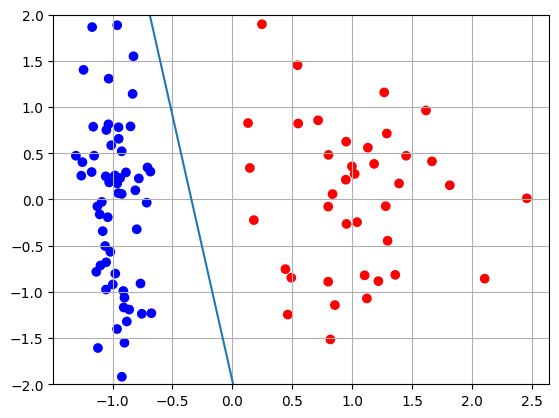

In [10]:
x_line = np.linspace(-1, 1, 100)
y_line = m*x_line + b

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.plot(x_line, y_line)
plt.ylim(-2, 2)
plt.grid()
plt.show()